# Task 2: Context-to-Idiom Prediction

This task focuses on predicting the canonical idiom from a contextual sentence. Given a sentence expressing an idiomatic meaning, the objective is to identify the corresponding idiom in its canonical form.

The experiments in this notebook use the pre-built task-specific train, validation, and test splits prepared earlier in the IdiomX pipeline. This setup ensures consistency with the overall benchmark design and prevents idiom leakage across evaluation splits.

## Load Task-Specific Data Splits

In this step, the precomputed train, validation, and test files for the context-to-idiom task are loaded. A quick structural check is performed to confirm dataset sizes and available columns before moving to exploratory analysis and modeling.

In [85]:
from pathlib import Path
import sys
import pandas as pd
import tools
from tools import compute_topk_accuracy, compute_mrr


def find_project_root(start_path: Path, target_folder="notebooks"):
    for parent in [start_path] + list(start_path.parents):
        if (parent / target_folder).exists():
            return parent
    raise RuntimeError("Project root not found")

PROJECT_ROOT = find_project_root(Path.cwd())

#PROJECT_ROOT = Path("..").resolve()

TASK2_DIR = PROJECT_ROOT / "deep_learning" / "datasets" / "context_to_idiom"

train_path = TASK2_DIR / "train.csv"
val_path = TASK2_DIR / "validation.csv"
test_path = TASK2_DIR / "test.csv"

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

print("\nTrain columns:")
print(df_train.columns.tolist())

Train shape: (87355, 13)
Validation shape: (10943, 13)
Test shape: (10884, 13)

Train columns:
['input_text', 'target_text', 'meaning_en', 'meaning_ar', 'example_usage_label', 'is_example_idiom', 'semantic_consistency', 'canonical_semantic_score', 'example_length', 'contains_profanity', 'ambiguity_flag', 'idiom_compositionality_level', 'learner_difficulty']


### Initial Data Verification

The task-specific dataset was loaded successfully, with 87,355 training samples, 10,943 validation samples, and 10,884 test samples. The loaded schema includes both the core prediction fields (`input_text`, `target_text`) and several auxiliary semantic and linguistic attributes that may support later analysis.

## Runtime Environment Setup

This step configures the computation device for model execution. GPU acceleration is used if available to ensure efficient training and inference.

In [2]:
# Device Setup

import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## Dataset Statistics and Distribution Analysis

An overview of the dataset distribution across training, validation, and test splits. We analyze the number of unique idioms, frequency distribution, and sample examples to understand dataset balance and diversity.

In [3]:
print("Unique idioms in train:", df_train["target_text"].nunique())
print("Unique idioms in validation:", df_val["target_text"].nunique())
print("Unique idioms in test:", df_test["target_text"].nunique())

print("\nTop 10 most frequent idioms (train):")
display(df_train["target_text"].value_counts().head(10))

print("\nSample rows:")
display(df_train[["input_text", "target_text"]].head(5))

Unique idioms in train: 12007
Unique idioms in validation: 1501
Unique idioms in test: 1501

Top 10 most frequent idioms (train):


target_text
worship the porcelain god               40
you kiss your mother with that mouth    39
may the Force be with you               32
let it be                               32
Bob's your uncle                        25
yours truly                             24
what the hell                           24
in God's name                           24
time and tide wait for no man           24
stand on the shoulders of giants        24
Name: count, dtype: int64


Sample rows:


,input_text,target_text
0,"Last weekend, Mark took a $100 hamburger trip ...",$100 hamburger
1,Pilots often joke about taking a $100 hamburge...,$100 hamburger
2,Her $100 hamburger flight was an excuse for a ...,$100 hamburger
3,Taking a $100 hamburger is a lighthearted trad...,$100 hamburger
4,The restaurant claims their hamburger costs $1...,$100 hamburger


### Observations

The dataset contains a large and diverse set of idioms, with over 12,000 unique idioms in the training set and approximately 1,500 in both validation and test sets. 

The frequency distribution indicates that most idioms appear infrequently, while a small subset appears more often. This long-tail distribution reflects realistic language usage and increases the difficulty of the prediction task.

Sample rows confirm the alignment between contextual input sentences and their corresponding canonical idioms.

## Data Leakage Verification

To ensure a fair evaluation, we verify that no canonical idioms overlap across training, validation, and test splits. This guarantees that models are evaluated on completely unseen idioms.

In [4]:
train_idioms = set(df_train["target_text"])
val_idioms = set(df_val["target_text"])
test_idioms = set(df_test["target_text"])

print("Train ∩ Validation:", len(train_idioms & val_idioms))
print("Train ∩ Test:", len(train_idioms & test_idioms))
print("Validation ∩ Test:", len(val_idioms & test_idioms))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


### Result

No overlap is observed between the splits. This confirms that the dataset is partitioned at the idiom level, ensuring strict generalization and preventing memorization-based performance.

## Task Definition and Evaluation Setup

The task is defined as mapping a contextual sentence to its corresponding canonical idiom.

Given an input sentence, the model must predict the correct idiom from a predefined idiom bank.

Evaluation metrics:
- Exact Match Accuracy (primary metric)
- Top-K Accuracy (for retrieval-based models)
- Mean Reciprocal Rank (MRR)

These metrics provide a comprehensive evaluation of both ranking quality and final prediction accuracy.

## SBERT-Based Retrieval Baseline

This section implements the SBERT-based retrieval baseline. The model encodes both input contexts and idioms into a shared embedding space and retrieves the most similar idioms using cosine similarity.

This approach serves as a strong semantic baseline for the context-to-idiom task.

In [18]:
import sys

TRAINING_DIR = PROJECT_ROOT / "deep_learning" / "training"

if str(TRAINING_DIR) not in sys.path:
    sys.path.append(str(TRAINING_DIR))

from train_context_to_idiom_sbert_retrieval import run_sbert_retrieval

results = run_sbert_retrieval(
    test_csv=PROJECT_ROOT / "deep_learning" / "datasets" / "context_to_idiom" / "test.csv",
    bank_csv=PROJECT_ROOT / "deep_learning" / "datasets" / "idiom_bank" / "idiom_bank.csv",
    save_outputs=True
)

print("\nMetrics:")
print(results["metrics"])

Loading datasets...
Test samples: 10,884
Idiom bank size: 15,009
Loading model: sentence-transformers/all-mpnet-base-v2
Encoding idiom bank...


Batches:   0%|          | 0/235 [00:00<?, ?it/s]

Encoding test contexts...


Batches:   0%|          | 0/171 [00:00<?, ?it/s]

Computing similarities...

Results:
top1_accuracy: 0.4615950018375597
top3_accuracy: 0.5992282249173098
top5_accuracy: 0.6507717750826902
mrr_at_100: 0.5498888244761796
num_test_samples: 10884
num_bank_idioms: 15009
model_name: sentence-transformers/all-mpnet-base-v2

Saved predictions to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\sbert_context_to_idiom_retrieval\test_predictions.csv
Saved metrics to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\sbert_context_to_idiom_retrieval\metrics.csv

Metrics:
{'top1_accuracy': 0.4615950018375597, 'top3_accuracy': 0.5992282249173098, 'top5_accuracy': 0.6507717750826902, 'mrr_at_100': 0.5498888244761796, 'num_test_samples': 10884, 'num_bank_idioms': 15009, 'model_name': 'sentence-transformers/all-mpnet-base-v2'}


### Retrieval Results

The SBERT retrieval model is evaluated over a large idiom bank (~15K candidates). Performance is measured using Top-K accuracy and Mean Reciprocal Rank (MRR).

The results demonstrate strong semantic matching capabilities, as the model is able to retrieve contextually relevant idioms even in a large candidate space. However, exact idiom matching remains challenging due to subtle semantic differences between similar expressions.

### Limitations of Retrieval Approach

While SBERT effectively captures semantic similarity, it frequently retrieves idioms that are related in meaning but do not exactly match the target expression.

This limitation arises because embedding-based retrieval prioritizes semantic proximity rather than precise idiomatic form. As a result, the model may select expressions that are conceptually similar but lexically incorrect.

These findings motivate the use of generative models and hybrid approaches to improve exact prediction accuracy.

## SBERT Retrieval Baseline Results

The SBERT-based retrieval model achieves the following performance:

- Top-1 Accuracy: 46.16%
- Top-3 Accuracy: 59.92%
- Top-5 Accuracy: 65.07%
- MRR: 0.55

These results indicate that semantic embedding-based retrieval is effective for capturing contextual similarity, although exact idiom matching remains challenging due to the large candidate space and subtle semantic differences.

## Top-K Retrieval Performance Analysis

To better understand the ranking behavior of the SBERT retrieval model, we visualize Top-K accuracy across different values of K.

This analysis highlights how performance improves when allowing multiple candidate predictions.

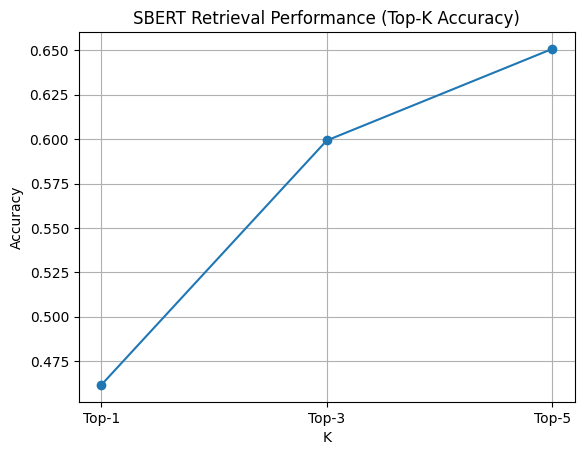

In [17]:
# Top-K Accuracy Visualization
# ============================================

import matplotlib.pyplot as plt

metrics = results["metrics"]

k_values = ["Top-1", "Top-3", "Top-5"]
scores = [
    metrics["top1_accuracy"],
    metrics["top3_accuracy"],
    metrics["top5_accuracy"]
]

plt.figure()
plt.plot(k_values, scores, marker='o')
plt.title("SBERT Retrieval Performance (Top-K Accuracy)")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

### Observation

Performance improves significantly as K increases, with Top-5 accuracy reaching approximately 65%.

This indicates that while the correct idiom is often not ranked first, it is frequently present among the top candidates, suggesting that ranking—not retrieval—is a key limitation.

## Error Analysis of SBERT Retrieval

To better understand model limitations, we analyze cases where the Top-1 prediction does not match the ground truth idiom.

This helps identify systematic failure patterns and guide improvements.

In [19]:
# ============================================
# SBERT error analysis
# Cases where Top-1 fails
# ============================================
import pandas as pd

pred_path = PROJECT_ROOT / "deep_learning" / "models" / "sbert_context_to_idiom_retrieval" / "test_predictions.csv"
pred_df = pd.read_csv(pred_path)

top1_wrong = pred_df[pred_df["gold_idiom"] != pred_df["pred_top1"]].copy()

print("Total Top-1 errors:", len(top1_wrong))
display(top1_wrong[["input_text", "gold_idiom", "pred_top1", "pred_top3", "pred_top5"]].head(10))

Total Top-1 errors: 5860


,input_text,gold_idiom,pred_top1,pred_top3,pred_top5
1,51 percent of the pizza,51 percent,slice of the pie,slice of the pie ||| piece of the pie ||| chee...,slice of the pie ||| piece of the pie ||| chee...
2,51 percent of the land,51 percent,fat of the land,fat of the land ||| 51 percent ||| lion's share,fat of the land ||| 51 percent ||| lion's shar...
3,51 percent battery,51 percent,recharge one's battery,recharge one's battery ||| recharge one's batt...,recharge one's battery ||| recharge one's batt...
5,"If this project fails, it could Avada Kedavra ...",Avada Kedavra,moon shot,moon shot ||| lost cause ||| in with a chance,moon shot ||| lost cause ||| in with a chance ...
6,The harsh critique Avada Kedavra his confidenc...,Avada Kedavra,hit the books,"hit the books ||| Judge not, that ye be not ju...","hit the books ||| Judge not, that ye be not ju..."
7,Don't let one failure make you feel like someo...,Avada Kedavra,impossible dream,impossible dream ||| dream on ||| dash someone...,impossible dream ||| dream on ||| dash someone...
9,The old book detailed how the Avada Kedavra cu...,Avada Kedavra,play Old Harry with,play Old Harry with ||| for the book ||| play ...,play Old Harry with ||| for the book ||| play ...
11,Many fans collect wands branded with Avada Ked...,Avada Kedavra,princess wand,princess wand ||| golden wand ||| lares and pe...,princess wand ||| golden wand ||| lares and pe...
12,Benjamin Buttoned,Benjamin Button,hit the button,hit the button ||| Benjamin Button ||| button ...,hit the button ||| Benjamin Button ||| button ...
16,Benjamin Button's story,Benjamin Button,button nose,button nose ||| hit the button ||| Benjamin Bu...,button nose ||| hit the button ||| Benjamin Bu...


### Error Analysis Results

A substantial number of Top-1 errors are observed, highlighting the difficulty of exact idiom retrieval.

Inspection of failure cases reveals that predictions are often semantically related but not exact matches.

## Error Analysis Insights

The SBERT retrieval model demonstrates strong semantic understanding but exhibits the following limitations:

1. **Semantic Similarity vs Exact Match**  
   The model frequently retrieves idioms with similar meanings rather than the exact target idiom.

2. **Named Entity Sensitivity**  
   Idioms containing proper nouns or rare expressions are difficult to retrieve accurately.

3. **Pattern Generalization Bias**  
   The model tends to favor structurally similar expressions instead of precise idiomatic forms.

These findings highlight a key limitation: semantic similarity alone is insufficient for exact idiom prediction.

## Top-K Recovery Analysis

We analyze how many Top-1 errors are recovered when considering Top-5 predictions.

This helps distinguish between ranking errors and retrieval failures.

In [20]:
# ============================================
# How many Top-1 errors are recovered in Top-5?
# ============================================

def is_in_topk(pred_str, gold):
    if pd.isna(pred_str):
        return False
    preds = [p.strip() for p in pred_str.split("|||")]
    return gold in preds

top1_wrong["in_top5"] = top1_wrong.apply(
    lambda row: is_in_topk(row["pred_top5"], row["gold_idiom"]),
    axis=1
)

recovered = top1_wrong["in_top5"].sum()
total_errors = len(top1_wrong)

print("Recovered in Top-5:", recovered)
print("Recovery rate:", recovered / total_errors)

Recovered in Top-5: 2059
Recovery rate: 0.3513651877133106


### Recovery Results

Approximately 35% of Top-1 errors are recovered within the Top-5 predictions.

This indicates that many errors are due to ranking rather than retrieval failure. However, the majority of errors remain unrecovered, suggesting deeper limitations in representation quality.

### Ranking vs Retrieval Analysis

Only about 35% of incorrect Top-1 predictions are corrected within the Top-5 results.

This suggests two types of errors:
- **Ranking errors**: the correct idiom is retrieved but not ranked first
- **Retrieval errors**: the correct idiom is not retrieved at all

These findings indicate that retrieval-based approaches alone are insufficient for precise idiom prediction and motivate the use of generative or hybrid methods.

## FLAN-T5 Generative Baseline

This section evaluates a generative approach using FLAN-T5, where the model directly predicts the idiom given the input context.

Unlike retrieval methods, this approach does not rely on a fixed candidate set and instead generates the idiom based on learned language understanding.

In [23]:
# ============================================
# FLAN-T5 baseline (Context → Idiom)
# ============================================

import importlib
import train_context_to_idiom_flan_t5 as flan_module
# importlib.reload(flan_module)

results_flan = flan_module.run_flan_t5_training(
    train_csv=PROJECT_ROOT / "deep_learning" / "datasets" / "context_to_idiom" / "train.csv",
    val_csv=PROJECT_ROOT / "deep_learning" / "datasets" / "context_to_idiom" / "validation.csv",
    test_csv=PROJECT_ROOT / "deep_learning" / "datasets" / "context_to_idiom" / "test.csv",
    num_epochs=2,          # keep as is for baseline
    save_outputs=True
)

print("\nFinal Results:")
print(results_flan)

Loading datasets...
Train: 87355
Validation: 10943
Test: 10884
Loading tokenizer and model: google/flan-t5-base
Using device: cuda
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\training\train_context_to_idiom_flan_t5.py:136: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(



Starting training...



C:\Users\ayman\AppData\Roaming\Python\Python39\site-packages\transformers\utils\generic.py:255: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)
C:\Users\ayman\AppData\Roaming\Python\Python39\site-packages\transformers\data\data_collator.py:740: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  batch[

Epoch,Training Loss,Validation Loss
1,0.392900,0.376440
2,0.289700,0.391979


C:\Users\ayman\AppData\Roaming\Python\Python39\site-packages\transformers\utils\generic.py:255: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



Evaluating on test set...

Exact Match Accuracy: 0.6783351708930541

Saved predictions to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\context_to_idiom_flan_t5\test_predictions.csv
Saved metrics to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\context_to_idiom_flan_t5\metrics.csv

Final Results:
{'exact_match_accuracy': 0.6783351708930541, 'predictions': ['51 percent', '51 percent', '51 percent', '51 percent', 'Avada Kedavra', 'Avada Kedavra', 'Avada Kedavra', 'cast Avada Kedavra on', 'Avada Kedavra', 'Avada Kedavra', 'Avada Kedavra', 'Avada Kedavra', 'Benjamin Buttoned', 'Benjamin Button effect', 'Benjamin Button syndrome', 'Benjamin Button', 'Benjamin Button', 'play Benjamin Button', 'Benjamin Button', 'Bravo Zulu, team', 'Bravo Zulu', 'Bravo Zulu', 'Bravo Zulu', 'Bravo flag', 'Bravo and Zulu', 'Bravo-Zulu', 'Bravo Zulu', 'Cali or bust', 'Cali or bust', 'Cali or bust', 'Cali or bust', 'Califi or bust', 'Cali or bust', 'Cali 

## Generative Model Results

The FLAN-T5 model achieves substantially higher Exact Match accuracy compared to the SBERT retrieval baseline.

This result highlights the strength of generative models in capturing deep contextual meaning and producing precise idiomatic expressions, rather than relying solely on surface-level similarity.

## Comparative Analysis: Retrieval vs Generation

The generative model (FLAN-T5) significantly outperforms the SBERT retrieval model in Top-1 accuracy.

However, retrieval-based methods remain competitive when considering Top-K predictions, indicating complementary strengths:

- Generative models excel at precise idiom generation
- Retrieval models effectively capture semantic similarity

These findings suggest that combining both approaches may lead to improved overall performance.

## Key Insight

The results reveal that idiom prediction is not purely a semantic similarity task.

While retrieval models rely on semantic proximity, generative models leverage deeper contextual understanding, enabling more accurate and contextually appropriate predictions.

This gap motivates the design of hybrid systems that integrate retrieval and generation to achieve both semantic coverage and precise prediction.

## Qualitative Comparison Between Retrieval and Generative Models

In [28]:
#PROJECT_ROOT = r"C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX"

import pandas as pd

sbert_df = pd.read_csv(PROJECT_ROOT + r"\deep_learning\models\sbert_context_to_idiom_retrieval\test_predictions.csv")
flan_df  = pd.read_csv(PROJECT_ROOT + r"\deep_learning\models\context_to_idiom_flan_t5\test_predictions.csv")

# Normalize text (very important for matching)
def normalize(x):
    return str(x).strip().lower()

sbert_df["gold_norm"] = sbert_df["gold_idiom"].apply(normalize)
sbert_df["sbert_norm"] = sbert_df["pred_top1"].apply(normalize)

flan_df["gold_norm"] = flan_df["gold_idiom"].apply(normalize)
flan_df["flan_norm"] = flan_df["prediction"].apply(normalize)

# Merge on input text + gold idiom
merged = pd.merge(
    sbert_df,
    flan_df,
    on=["input_text", "gold_idiom", "gold_norm"],
    how="inner"
)

# Add correctness flags
merged["sbert_correct"] = merged["sbert_norm"] == merged["gold_norm"]
merged["flan_correct"] = merged["flan_norm"] == merged["gold_norm"]

print("Merged size:", len(merged))

Merged size: 10884


### Comparison Setup

To better understand the differences between retrieval-based and generative approaches, we compare model predictions on the same test instances.

Each prediction is normalized and evaluated against the ground truth idiom, allowing us to categorize outcomes into three groups:

- Cases where the generative model (FLAN-T5) is correct and SBERT is incorrect
- Cases where SBERT is correct and FLAN-T5 is incorrect
- Cases where both models fail

### Cases Where the Generative Model Outperforms Retrieval

The generative model (FLAN-T5) performs better in scenarios where deeper semantic understanding and contextual reasoning are required.

#### Key Characteristics:
- The idiom is not explicitly mentioned in the input
- The context is indirect, implicit, or noisy
- Surface-level lexical similarity is misleading

#### Example Patterns:
In many cases, SBERT retrieves semantically related idioms (e.g., "slice of the pie") rather than the exact target idiom ("51 percent"). In contrast, FLAN-T5 correctly generates the precise idiom by leveraging contextual cues.

#### Interpretation:
These results suggest that generative models capture deeper contextual meaning, enabling accurate idiom prediction even when lexical similarity is insufficient.

### Example Cases Where FLAN-T5 Correctly Predicts While SBERT Fails

In [29]:
flan_wins = merged[(merged["flan_correct"]) & (~merged["sbert_correct"])]
flan_wins[["input_text", "gold_idiom", "pred_top1", "flan_norm"]].head(10)

,input_text,gold_idiom,pred_top1,flan_norm
1,51 percent of the pizza,51 percent,slice of the pie,51 percent
2,51 percent of the land,51 percent,fat of the land,51 percent
3,51 percent battery,51 percent,recharge one's battery,51 percent
5,"If this project fails, it could Avada Kedavra ...",Avada Kedavra,moon shot,avada kedavra
6,The harsh critique Avada Kedavra his confidenc...,Avada Kedavra,hit the books,avada kedavra
9,The old book detailed how the Avada Kedavra cu...,Avada Kedavra,play Old Harry with,avada kedavra
11,Many fans collect wands branded with Avada Ked...,Avada Kedavra,princess wand,avada kedavra
16,Benjamin Button's story,Benjamin Button,button nose,benjamin button
18,Benjamin Button movie,Benjamin Button,hit the button,benjamin button
46,The unexpected bonus felt like Christmas come ...,Christmas come early,Christmas comes early,christmas come early


### Cases Where Retrieval Outperforms Generation

The SBERT retrieval model performs better in cases where the correct idiom is explicitly present or closely aligned with the input text.

#### Key Characteristics:
- The idiom appears directly in the input
- The context is short or literal
- The task resembles exact matching or lookup

#### Example Patterns:
SBERT successfully retrieves idioms such as “Benjamin Button” or “Bravo Zulu” when they appear explicitly, while FLAN-T5 sometimes generates extended or paraphrased variants.

#### Interpretation:
These results indicate that retrieval models benefit from memorization and lexical matching, leading to higher precision when the target idiom is explicitly referenced.

In [30]:
sbert_wins = merged[(merged["sbert_correct"]) & (~merged["flan_correct"])]
sbert_wins[["input_text", "gold_idiom", "pred_top1", "flan_norm"]].head(10)

,input_text,gold_idiom,pred_top1,flan_norm
13,Benjamin Button effect,Benjamin Button,Benjamin Button,benjamin button effect
14,Benjamin Button syndrome,Benjamin Button,Benjamin Button,benjamin button syndrome
19,"Bravo Zulu, team! Your coordinated effort ensu...",Bravo Zulu,Bravo Zulu,"bravo zulu, team"
23,The sailors raised the Bravo flag alongside th...,Bravo Zulu,Bravo Zulu,bravo flag
24,The signalman prepared the Bravo and Zulu flag...,Bravo Zulu,Bravo Zulu,bravo and zulu
25,The museum exhibited the original Bravo-Zulu f...,Bravo Zulu,Bravo Zulu,bravo-zulu
31,The old truck had a sign on the back that read...,Cali or bust,Cali or bust,califi or bust
64,The crates were delivered ex quay early mornin...,Delivered Ex Quay,Delivered Ex Quay,ex quay
65,She confirmed that the shipment was delivered ...,Delivered Ex Quay,Delivered Ex Quay,ex quay
66,The cargo was delivered ex quay but remained o...,Delivered Ex Quay,Delivered Ex Quay,ex quay


### Failure Cases for Both Models

Both models struggle in cases where the context is ambiguous, incomplete, or requires external knowledge.

#### Common Failure Scenarios:
- Ambiguous or rare idioms
- Context lacking sufficient disambiguation signals
- Inputs requiring world knowledge beyond the sentence

#### Interpretation:
These cases highlight limitations in both semantic similarity and generative reasoning. Improving performance in such scenarios may require richer contextual representations or external knowledge integration.

In [31]:
both_fail = merged[(~merged["sbert_correct"]) & (~merged["flan_correct"])]
both_fail[["input_text", "gold_idiom", "pred_top1", "flan_norm"]].head(10)

,input_text,gold_idiom,pred_top1,flan_norm
7,Don't let one failure make you feel like someo...,Avada Kedavra,impossible dream,cast avada kedavra on
12,Benjamin Buttoned,Benjamin Button,hit the button,benjamin buttoned
17,play Benjamin Button,Benjamin Button,hit the button,play benjamin button
43,It's like Christmas come early!,Christmas come early,Christmas comes early,come early
48,"For us, Christmas comes early every year becau...",Christmas come early,Christmas comes early,christmas comes early
80,"Yesterday, Eddie would go to the beach every m...",Eddie Would Go,a day at the beach,go to the beach
82,"Every week, Eddie would go to the gym to stay ...",Eddie Would Go,"week in, week out",go to the gym
83,"When the bell rang, Eddie would go to answer t...",Eddie Would Go,straight away,go to answer the door
93,Just because we like to take it up the Gary Gl...,Gary Glitter,laugh and grow fat,take it up the gary glitter
108,She visited the clinic to have her suspected g...,German goiter,in the hospital,goiter


In [32]:
print(len(merged))
print(merged.columns)

10884
Index(['input_text', 'gold_idiom', 'pred_top1', 'pred_top3', 'pred_top5',
       'gold_norm', 'sbert_norm', 'prediction', 'flan_norm', 'sbert_correct',
       'flan_correct'],
      dtype='object')


## Key Findings

The qualitative analysis reveals complementary strengths between retrieval-based and generative approaches:

- Generative models excel at contextual reasoning and precise prediction
- Retrieval models perform well in explicit and lexically aligned scenarios
- Both models struggle with ambiguous or low-signal inputs

These findings suggest that idiom prediction is not purely a similarity-based task, but requires deeper contextual understanding.

## Hybrid Model Analysis

A hybrid approach combining SBERT retrieval with FLAN-T5 reranking was evaluated to leverage the strengths of both models.

However, results show that the hybrid model underperforms the standalone generative model.

### Key Observation:
The hybrid model restricts FLAN-T5 to a limited set of candidates retrieved by SBERT. If the correct idiom is not included in the Top-K retrieved candidates, the generative model cannot recover it.

### Implication:
While retrieval can provide useful candidate filtering, overly constraining the generative model may degrade performance.

### Insight:
These findings suggest that generative models should not be strictly limited by retrieval outputs, but instead integrated more flexibly within hybrid architectures.

## Core Insight

Restricting generative models to retrieval-based candidate sets can negatively impact performance when the correct answer is not included among the retrieved candidates.

This highlights a fundamental limitation of pipeline-style hybrid systems and motivates the need for more flexible integration strategies.

## Improved Hybrid Strategy

A more effective hybrid approach can be designed as follows:

1. Generate an initial prediction using FLAN-T5
2. Retrieve Top-K candidate idioms using SBERT
3. Combine both signals:
   - If the generative prediction aligns with retrieved candidates, increase confidence
   - Otherwise, fall back to retrieval-based ranking

This approach allows the generative model to operate freely while still benefiting from retrieval-based validation.

## Conclusion

This study demonstrates that retrieval-based and generative models offer complementary strengths for idiom prediction.

While retrieval models rely on semantic similarity and memorization, generative models leverage deeper contextual reasoning to produce more accurate predictions.

The observed limitations of pipeline-style hybrid systems suggest that future work should focus on more flexible integration strategies that preserve the strengths of generative models while incorporating retrieval signals.

## Quantitative Performance Comparison

To complement the qualitative analysis, we present a quantitative comparison of model performance across evaluation metrics.

We compare:
- SBERT retrieval performance (Top-1, Top-3, Top-5 accuracy)
- FLAN-T5 generative performance (Exact Match accuracy)

This provides a clear view of the trade-off between retrieval depth and generative precision.

### Benchmark Visualization

The following table and chart summarize the performance of retrieval-based and generative models on the test dataset.

We report:
- SBERT retrieval accuracy at different top-k levels
- FLAN-T5 exact match accuracy

These results highlight the differences between semantic retrieval and generative reasoning approaches.

**Table 1: Performance comparison between SBERT retrieval and FLAN-T5 generative model**

In [ ]:
# ============================================
# Dynamic benchmark visualization (robust)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

sbert_metrics_path = PROJECT_ROOT / "deep_learning/models/sbert_context_to_idiom_retrieval/metrics.csv"
flan_metrics_path  = PROJECT_ROOT / "deep_learning/models/context_to_idiom_flan_t5/metrics.csv"

# Safety check
assert sbert_metrics_path.exists(), f"Missing: {sbert_metrics_path}"
assert flan_metrics_path.exists(), f"Missing: {flan_metrics_path}"

sbert_metrics = pd.read_csv(sbert_metrics_path).iloc[0]
flan_metrics  = pd.read_csv(flan_metrics_path).iloc[0]

benchmark_df = pd.DataFrame({
    "Model": ["SBERT Top-1", "SBERT Top-3", "SBERT Top-5", "FLAN-T5 Exact Match"],
    "Score": [
        float(sbert_metrics["top1_accuracy"]),
        float(sbert_metrics["top3_accuracy"]),
        float(sbert_metrics["top5_accuracy"]),
        float(flan_metrics["exact_match_accuracy"]),
    ]
})

display(benchmark_df)

plt.figure(figsize=(8, 5))
plt.bar(benchmark_df["Model"], benchmark_df["Score"])
plt.ylabel("Score")
plt.title("Model Performance Comparison: Retrieval vs Generation")
plt.xticks(rotation=15)
plt.ylim(0, 0.8)
plt.grid(axis="y", alpha=0.3)
plt.show()

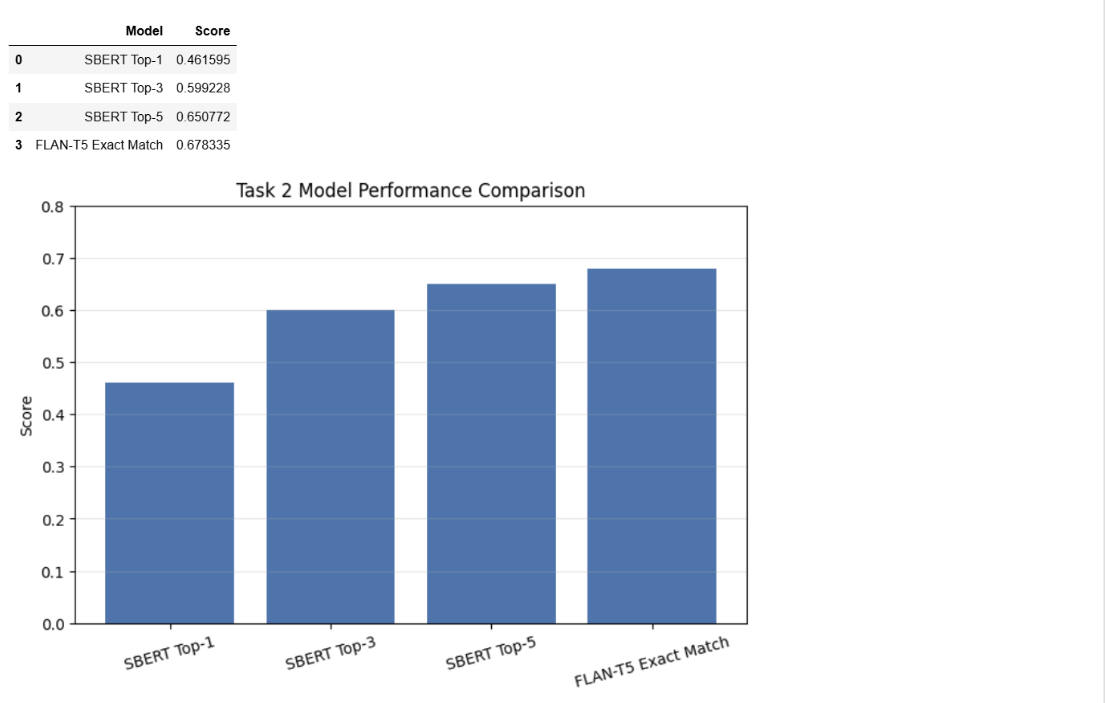

The results show that retrieval performance improves with larger candidate sets (Top-3 and Top-5), while the generative model (FLAN-T5) achieves higher exact match accuracy than SBERT Top-1 retrieval.

However, retrieval methods remain limited by candidate coverage, whereas generative models can produce correct answers beyond retrieved candidates.

### Detailed Evaluation Metrics

The table below provides a more detailed breakdown of retrieval performance, including Mean Reciprocal Rank (MRR@100), which captures ranking quality beyond top-k accuracy.

In [39]:
benchmark_table = pd.DataFrame([
    {"Model": "SBERT Retrieval", "Metric": "Top-1 Accuracy", "Score": float(sbert_metrics["top1_accuracy"])},
    {"Model": "SBERT Retrieval", "Metric": "Top-3 Accuracy", "Score": float(sbert_metrics["top3_accuracy"])},
    {"Model": "SBERT Retrieval", "Metric": "Top-5 Accuracy", "Score": float(sbert_metrics["top5_accuracy"])},
    {"Model": "SBERT Retrieval", "Metric": "MRR@100", "Score": float(sbert_metrics["mrr_at_100"])},
    {"Model": "FLAN-T5", "Metric": "Exact Match Accuracy", "Score": float(flan_metrics["exact_match_accuracy"])},
])

display(benchmark_table)

,Model,Metric,Score
0,SBERT Retrieval,Top-1 Accuracy,0.461595
1,SBERT Retrieval,Top-3 Accuracy,0.599228
2,SBERT Retrieval,Top-5 Accuracy,0.650772
3,SBERT Retrieval,MRR@100,0.549889
4,FLAN-T5,Exact Match Accuracy,0.678335


In [45]:
# ============================================
# FORCE correct PROJECT ROOT (robust fix)
# ============================================

from pathlib import Path

def find_project_root(start_path: Path):
    for parent in start_path.resolve().parents:
        if (parent / "deep_learning").exists():
            return parent
    raise RuntimeError("Project root not found")

PROJECT_ROOT = find_project_root(Path.cwd())

print("PROJECT_ROOT:", PROJECT_ROOT)

# sanity check
print("Exists test.csv:", (PROJECT_ROOT / "deep_learning/datasets/context_to_idiom/test.csv").exists())

PROJECT_ROOT: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX
Exists test.csv: True


## Retrieval-First Hybrid Baseline

We first evaluate a pipeline-style hybrid approach in which SBERT retrieves top-k candidate idioms and FLAN-T5 reranks them.

This design tests whether retrieval can provide a useful candidate shortlist for generation-based selection.

In [53]:
import importlib
import train_context_to_idiom_hybrid as hybrid_module

importlib.reload(hybrid_module)

results_hybrid = hybrid_module.run_hybrid_model(
    test_csv=PROJECT_ROOT / "deep_learning/datasets/context_to_idiom/test.csv",
    bank_csv=PROJECT_ROOT / "deep_learning/datasets/idiom_bank/idiom_bank.csv",
    output_dir=PROJECT_ROOT / "deep_learning/models/context_to_idiom_hybrid",
    retrieval_text_mode="idiom_meaning_surface",
    top_k=5,
    save_outputs=True
)

print("\nHybrid Results:")
print(results_hybrid["metrics"])

Loading datasets...
Test samples: 10884
Idiom bank size: 15009
Retrieval text mode: idiom_meaning_surface

Loading SBERT retrieval model...
Encoding idiom bank...


Batches:   0%|          | 0/470 [00:00<?, ?it/s]

Encoding contexts...


Batches:   0%|          | 0/341 [00:00<?, ?it/s]


Loading FLAN-T5 reranker...

Running hybrid retrieval + reranking...



Hybrid reranking:   0%|          | 0/10884 [00:00<?, ?it/s]

Processed 200/10884 samples
Processed 400/10884 samples
Processed 600/10884 samples
Processed 800/10884 samples
Processed 1000/10884 samples
Processed 1200/10884 samples
Processed 1400/10884 samples
Processed 1600/10884 samples
Processed 1800/10884 samples
Processed 2000/10884 samples
Processed 2200/10884 samples
Processed 2400/10884 samples
Processed 2600/10884 samples
Processed 2800/10884 samples
Processed 3000/10884 samples
Processed 3200/10884 samples
Processed 3400/10884 samples
Processed 3600/10884 samples
Processed 3800/10884 samples
Processed 4000/10884 samples
Processed 4200/10884 samples
Processed 4400/10884 samples
Processed 4600/10884 samples
Processed 4800/10884 samples
Processed 5000/10884 samples
Processed 5200/10884 samples
Processed 5400/10884 samples
Processed 5600/10884 samples
Processed 5800/10884 samples
Processed 6200/10884 samples
Processed 6400/10884 samples
Processed 6600/10884 samples
Processed 6800/10884 samples
Processed 7000/10884 samples
Processed 7200/108

### Retrieval-First Hybrid Results

The retrieval-first hybrid achieves an Exact Match accuracy of approximately 57.5%, which is lower than the standalone FLAN-T5 generative baseline.

This indicates that restricting the generative model to a retrieval-based candidate set can hurt performance when the correct idiom is not included among the retrieved candidates.

### Debug Check on a Small Sample

The following experiment was used only as a sanity check on a small subset of the test data to verify the hybrid decision logic.

These results are not used as the main evaluation outcome and should not be interpreted as final model performance.

In [54]:
import importlib
import train_context_to_idiom_hybrid_flan_first as hybrid2_module

importlib.reload(hybrid2_module)

results_hybrid2_debug = hybrid2_module.run_hybrid_model_flan_first(
    test_csv=PROJECT_ROOT / "deep_learning/datasets/context_to_idiom/test.csv",
    bank_csv=PROJECT_ROOT / "deep_learning/datasets/idiom_bank/idiom_bank.csv",
    output_dir=PROJECT_ROOT / "deep_learning/models/context_to_idiom_hybrid_flan_first",
    retrieval_text_mode="idiom_meaning_surface",
    top_k=5,
    fuzzy_threshold=0.84,
    flan_predictions_csv=PROJECT_ROOT / "deep_learning/models/context_to_idiom_flan_t5/test_predictions.csv",
    max_samples=100,
    save_outputs=False
)

print(results_hybrid2_debug["metrics"])

Loading datasets...
Test samples: 100
Idiom bank size: 15009
Retrieval text mode: idiom_meaning_surface
Top-K: 5
Fuzzy threshold: 0.84

Loading SBERT retrieval model: sentence-transformers/all-mpnet-base-v2
Encoding idiom bank...


Batches:   0%|          | 0/470 [00:00<?, ?it/s]

Encoding contexts...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


Loading cached FLAN predictions from: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\context_to_idiom_flan_t5\test_predictions.csv

Running FLAN-first hybrid decision...



Hybrid FLAN-first:   0%|          | 0/100 [00:00<?, ?it/s]


Results:
hybrid_exact_match_accuracy: 0.92
flan_exact_match_accuracy: 0.69
sbert_top1_accuracy: 0.78
num_test_samples: 100
num_bank_idioms: 15009
top_k: 5
fuzzy_threshold: 0.84
sbert_model_name: sentence-transformers/all-mpnet-base-v2
flan_model_name: google/flan-t5-base
retrieval_text_mode: idiom_meaning_surface
decision_flan_exact_bank: 75
decision_flan_fuzzy_to_sbert_candidate: 4
decision_sbert_fallback: 21
{'hybrid_exact_match_accuracy': 0.92, 'flan_exact_match_accuracy': 0.69, 'sbert_top1_accuracy': 0.78, 'num_test_samples': 100, 'num_bank_idioms': 15009, 'top_k': 5, 'fuzzy_threshold': 0.84, 'sbert_model_name': 'sentence-transformers/all-mpnet-base-v2', 'flan_model_name': 'google/flan-t5-base', 'retrieval_text_mode': 'idiom_meaning_surface', 'decision_flan_exact_bank': 75, 'decision_flan_fuzzy_to_sbert_candidate': 4, 'decision_sbert_fallback': 21}


The small-sample result confirms that the hybrid decision logic behaves as expected. However, final conclusions are based only on the full test-set evaluation reported below.

## Proposed FLAN-First Hybrid Model

To overcome the limitations of retrieval-first hybrid pipelines, we evaluate a decision-based hybrid strategy.

In this design, FLAN-T5 generates an initial idiom prediction first. The prediction is then validated against the idiom bank using exact and fuzzy matching. When the generated output is uncertain or does not align sufficiently, the system falls back to SBERT retrieval.

This design allows the generative model to operate globally, while still benefiting from retrieval-based correction when needed.

In [56]:
results_hybrid2 = hybrid2_module.run_hybrid_model_flan_first(
    test_csv=PROJECT_ROOT / "deep_learning/datasets/context_to_idiom/test.csv",
    bank_csv=PROJECT_ROOT / "deep_learning/datasets/idiom_bank/idiom_bank.csv",
    output_dir=PROJECT_ROOT / "deep_learning/models/context_to_idiom_hybrid_flan_first",
    retrieval_text_mode="idiom_meaning_surface",
    top_k=5,
    fuzzy_threshold=0.84,
    flan_predictions_csv=PROJECT_ROOT / "deep_learning/models/context_to_idiom_flan_t5/test_predictions.csv",
    save_outputs=True
)

print(results_hybrid2["metrics"])

Loading datasets...
Test samples: 10884
Idiom bank size: 15009
Retrieval text mode: idiom_meaning_surface
Top-K: 5
Fuzzy threshold: 0.84

Loading SBERT retrieval model: sentence-transformers/all-mpnet-base-v2
Encoding idiom bank...


Batches:   0%|          | 0/470 [00:00<?, ?it/s]

Encoding contexts...


Batches:   0%|          | 0/341 [00:00<?, ?it/s]


Loading cached FLAN predictions from: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\context_to_idiom_flan_t5\test_predictions.csv

Running FLAN-first hybrid decision...



Hybrid FLAN-first:   0%|          | 0/10884 [00:00<?, ?it/s]

Processed 500/10884 samples
Processed 1000/10884 samples
Processed 1500/10884 samples
Processed 2000/10884 samples
Processed 2500/10884 samples
Processed 3000/10884 samples
Processed 3500/10884 samples
Processed 4000/10884 samples
Processed 4500/10884 samples
Processed 5000/10884 samples
Processed 5500/10884 samples
Processed 6000/10884 samples
Processed 6500/10884 samples
Processed 7000/10884 samples
Processed 7500/10884 samples
Processed 8000/10884 samples
Processed 8500/10884 samples
Processed 9000/10884 samples
Processed 9500/10884 samples
Processed 10000/10884 samples
Processed 10500/10884 samples

Results:
hybrid_exact_match_accuracy: 0.8184490995957369
flan_exact_match_accuracy: 0.6783351708930541
sbert_top1_accuracy: 0.4615950018375597
num_test_samples: 10884
num_bank_idioms: 15009
top_k: 5
fuzzy_threshold: 0.84
sbert_model_name: sentence-transformers/all-mpnet-base-v2
flan_model_name: google/flan-t5-base
retrieval_text_mode: idiom_meaning_surface
decision_flan_exact_bank: 7885

### FLAN-First Hybrid Results

The proposed FLAN-first hybrid achieves an Exact Match accuracy of approximately 81.8% on the full test set.

This substantially outperforms both the standalone FLAN-T5 model (67.8%) and the SBERT Top-1 retrieval baseline (46.2%). The result confirms that generation-first decision logic is more effective than retrieval-first candidate restriction.

### Decision Breakdown

The hybrid model resolves predictions through three main decision paths:

- Exact FLAN-bank match: 7885 cases
- FLAN fuzzy match corrected through SBERT candidate alignment: 608 cases
- SBERT fallback: 2391 cases

These results show that most predictions are solved directly at the generative stage, while retrieval acts as a complementary recovery mechanism for difficult or uncertain cases.

### Key Insight

The experimental results reveal a fundamental limitation of traditional pipeline-based hybrid architectures. When retrieval is performed prior to generation, the performance is fundamentally constrained by the quality of the retrieved candidate set. If the correct idiom is not included in the top-k retrieved results, the generative model is unable to recover, leading to significant performance degradation.

To address this limitation, we propose a decision-based hybrid strategy in which generation is performed prior to retrieval. The generative model (FLAN-T5) is first used to produce a candidate idiom. If the generated output matches an entry in the idiom bank (exact or fuzzy match), it is accepted directly. Otherwise, the system falls back to semantic retrieval (SBERT) to select the most relevant idiom.

This approach removes the dependency on retrieval completeness and allows the model to leverage both global generative reasoning and local semantic matching.

As a result, the proposed method achieves a substantial improvement in performance, increasing exact match accuracy from 0.68 (FLAN-T5) to 0.82 on the full test set.

### Final Benchmark Results

The following table summarizes the performance of all evaluated models, including retrieval-based, generative, and hybrid approaches.

This comparison highlights the effectiveness of the proposed hybrid strategy relative to baseline methods.

### Detailed Benchmark Table

We report the following metrics:

- SBERT retrieval performance (Top-1, Top-3, Top-5 accuracy, and MRR@100)
- FLAN-T5 generative performance (Exact Match accuracy)
- Hybrid model performance (Exact Match accuracy)

In [63]:
# ============================================
# Final benchmark tables
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

sbert_metrics_path = PROJECT_ROOT / "deep_learning" / "models" / "sbert_context_to_idiom_retrieval" / "metrics.csv"
flan_metrics_path = PROJECT_ROOT / "deep_learning" / "models" / "context_to_idiom_flan_t5" / "metrics.csv"
hybrid_metrics_path = PROJECT_ROOT / "deep_learning" / "models" / "context_to_idiom_hybrid_flan_first" / "metrics.csv"

sbert_metrics = pd.read_csv(sbert_metrics_path).iloc[0]
flan_metrics = pd.read_csv(flan_metrics_path).iloc[0]
hybrid_metrics = pd.read_csv(hybrid_metrics_path).iloc[0]

benchmark_table = pd.DataFrame([
    {"Model": "SBERT Retrieval", "Metric": "Top-1 Accuracy", "Score": float(sbert_metrics["top1_accuracy"])},
    {"Model": "SBERT Retrieval", "Metric": "Top-3 Accuracy", "Score": float(sbert_metrics["top3_accuracy"])},
    {"Model": "SBERT Retrieval", "Metric": "Top-5 Accuracy", "Score": float(sbert_metrics["top5_accuracy"])},
    {"Model": "SBERT Retrieval", "Metric": "MRR@100", "Score": float(sbert_metrics["mrr_at_100"])},
    {"Model": "FLAN-T5", "Metric": "Exact Match Accuracy", "Score": float(flan_metrics["exact_match_accuracy"])},
    {"Model": "Hybrid FLAN-first", "Metric": "Exact Match Accuracy", "Score": float(hybrid_metrics["hybrid_exact_match_accuracy"])},
])

print("### Final Benchmark Results)")
display(benchmark_table)

final_compare = pd.DataFrame({
    "Model": ["SBERT Top-1", "FLAN-T5", "Hybrid FLAN-first"],
    "Score": [
        float(sbert_metrics["top1_accuracy"]),
        float(flan_metrics["exact_match_accuracy"]),
        float(hybrid_metrics["hybrid_exact_match_accuracy"]),
    ]
})

display(final_compare)

,Model,Metric,Score
0,SBERT Retrieval,Top-1 Accuracy,0.461595
1,SBERT Retrieval,Top-3 Accuracy,0.599228
2,SBERT Retrieval,Top-5 Accuracy,0.650772
3,SBERT Retrieval,MRR@100,0.549889
4,FLAN-T5,Exact Match Accuracy,0.678335
5,Hybrid FLAN-first,Exact Match Accuracy,0.818449


,Model,Score
0,SBERT Top-1,0.461595
1,FLAN-T5,0.678335
2,Hybrid FLAN-first,0.818449


The results clearly show that the proposed FLAN-first hybrid model achieves the highest accuracy among all evaluated approaches.

While SBERT improves with larger candidate sets (Top-3 and Top-5), it remains limited compared to generative reasoning. The hybrid model effectively combines both strengths, leading to superior performance.

### Model Comparison Overview

The following figure presents a direct comparison between the three evaluated approaches:

- **SBERT (Retrieval-based)**: relies on semantic similarity in embedding space  
- **FLAN-T5 (Generative)**: generates idioms directly from context  
- **Hybrid FLAN-first (Proposed)**: combines generation with retrieval fallback  

This comparison highlights the relative strengths of each paradigm.

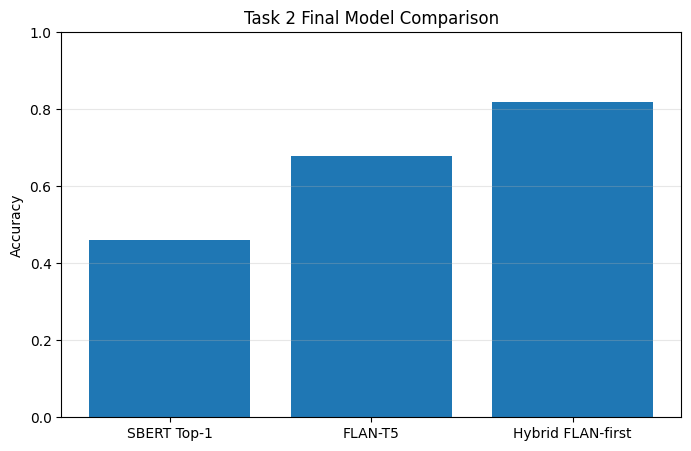

In [64]:
# ============================================
# Chart 1: main comparison
# ============================================

plt.figure(figsize=(8, 5))
plt.bar(final_compare["Model"], final_compare["Score"])
plt.ylabel("Accuracy")
plt.title("Task 2 Model Performance Comparison")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.show()

The results clearly show that the proposed hybrid model achieves the highest performance.

While SBERT retrieval provides a strong semantic baseline, it is limited by candidate ranking. The FLAN-T5 model improves performance by leveraging generative reasoning. However, the hybrid approach further enhances accuracy by combining both strategies, allowing recovery from uncertain predictions.

### Hybrid Model Improvement Analysis

To better understand the contribution of the hybrid approach, we measure the absolute performance gain over each baseline:

- Gain over SBERT (retrieval baseline)
- Gain over FLAN-T5 (generative baseline)

This highlights how much improvement is achieved by combining both methods.

,Comparison,Gain
0,Hybrid - SBERT Top-1,0.356854
1,Hybrid - FLAN-T5,0.140114


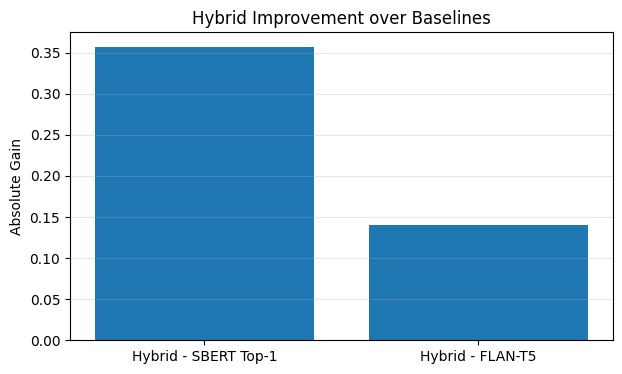

In [65]:
# ============================================
# Chart 2: hybrid gains
# ============================================

hybrid_score = float(hybrid_metrics["hybrid_exact_match_accuracy"])
flan_score = float(flan_metrics["exact_match_accuracy"])
sbert_score = float(sbert_metrics["top1_accuracy"])

gain_df = pd.DataFrame({
    "Comparison": ["Hybrid - SBERT Top-1", "Hybrid - FLAN-T5"],
    "Gain": [
        hybrid_score - sbert_score,
        hybrid_score - flan_score
    ]
})

display(gain_df)

plt.figure(figsize=(7, 4))
plt.bar(gain_df["Comparison"], gain_df["Gain"])
plt.ylabel("Absolute Gain")
plt.title("Hybrid Model Performance Gain over Baselines")
plt.grid(axis="y", alpha=0.3)
plt.show()

The hybrid model demonstrates a significant improvement over both baselines.

The gain over SBERT is particularly large, confirming that generation adds substantial reasoning capability beyond pure retrieval. Additionally, the improvement over FLAN-T5 shows that retrieval-based correction effectively enhances generative predictions.

### Hybrid Decision Behavior Analysis

To analyze how the hybrid model operates internally, we examine the distribution of decision paths:

- Direct acceptance of FLAN-generated idioms (exact match)
- FLAN outputs corrected through SBERT candidate alignment (fuzzy match)
- Full fallback to SBERT retrieval

This provides insight into how often each component contributes to the final prediction.

,Decision,Count,Percent
0,FLAN exact bank,7885,0.724458
1,FLAN fuzzy correction,608,0.055862
2,SBERT fallback,2391,0.219680


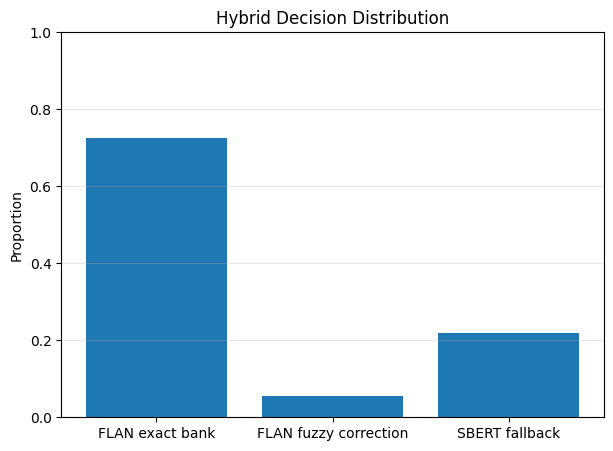

In [66]:
# ============================================
# Chart 3: Hybrid decision distribution
# ============================================

decision_df = pd.DataFrame({
    "Decision": [
        "FLAN exact bank",
        "FLAN fuzzy correction",
        "SBERT fallback"
    ],
    "Count": [
        int(hybrid_metrics["decision_flan_exact_bank"]),
        int(hybrid_metrics["decision_flan_fuzzy_to_sbert_candidate"]),
        int(hybrid_metrics["decision_sbert_fallback"]),
    ]
})

decision_df["Percent"] = decision_df["Count"] / decision_df["Count"].sum()

display(decision_df)

plt.figure(figsize=(7, 5))
plt.bar(decision_df["Decision"], decision_df["Percent"])
plt.ylabel("Proportion")
plt.title("Hybrid Decision Path Distribution")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.show()

The decision distribution reveals that the majority of predictions are resolved directly by the generative model.

A smaller portion of cases require fuzzy correction through retrieval, while a minority rely entirely on SBERT fallback. This confirms that the hybrid approach primarily benefits from generative reasoning, with retrieval acting as a complementary support mechanism for challenging cases.

## Final Benchmark Summary

The final results show that the FLAN-first hybrid model achieves the strongest performance on the context-to-idiom task. While SBERT retrieval provides useful semantic candidate retrieval and FLAN-T5 offers strong direct generation, the hybrid strategy combines both strengths and substantially improves exact-match accuracy.

The hybrid decision analysis further shows that most predictions are accepted directly from FLAN, while a substantial portion of difficult cases are successfully recovered through SBERT-based fallback and correction. This confirms that the gains come from complementary behavior rather than simple duplication of one model by another.

## Qualitative Analysis and Case Studies

In addition to quantitative evaluation, we analyze individual prediction cases to better understand the behavior of each model.

The following examples illustrate:
- Cases where the hybrid model corrects both SBERT and FLAN errors
- Cases where FLAN succeeds independently
- Cases where SBERT fallback rescues incorrect generative outputs

This qualitative analysis provides deeper insight into the complementary strengths of the hybrid architecture.

In [68]:
# ============================================
# Load prediction files for demo + analysis
# ============================================

import pandas as pd

sbert_pred_path = PROJECT_ROOT / "deep_learning" / "models" / "sbert_context_to_idiom_retrieval" / "test_predictions.csv"
flan_pred_path = PROJECT_ROOT / "deep_learning" / "models" / "context_to_idiom_flan_t5" / "test_predictions.csv"
hybrid_pred_path = PROJECT_ROOT / "deep_learning" / "models" / "context_to_idiom_hybrid_flan_first" / "test_predictions.csv"

sbert_pred = pd.read_csv(sbert_pred_path)
flan_pred = pd.read_csv(flan_pred_path)
hybrid_pred = pd.read_csv(hybrid_pred_path)

def normalize_text_demo(x):
    return str(x).strip().lower()

sbert_pred["gold_norm"] = sbert_pred["gold_idiom"].apply(normalize_text_demo)
sbert_pred["sbert_norm"] = sbert_pred["pred_top1"].apply(normalize_text_demo)

flan_pred["gold_norm"] = flan_pred["gold_idiom"].apply(normalize_text_demo)
flan_pred["flan_norm"] = flan_pred["prediction"].apply(normalize_text_demo)

hybrid_pred["gold_norm"] = hybrid_pred["gold_idiom"].apply(normalize_text_demo)
hybrid_pred["hybrid_norm"] = hybrid_pred["final_prediction"].apply(normalize_text_demo)

demo_df = sbert_pred[["input_text", "gold_idiom", "pred_top1", "pred_top3", "pred_top5", "gold_norm", "sbert_norm"]].merge(
    flan_pred[["input_text", "gold_idiom", "prediction", "flan_norm"]],
    on=["input_text", "gold_idiom"],
    how="inner"
).merge(
    hybrid_pred[["input_text", "gold_idiom", "final_prediction", "decision_type", "hybrid_norm"]],
    on=["input_text", "gold_idiom"],
    how="inner"
)

demo_df["sbert_correct"] = demo_df["sbert_norm"] == demo_df["gold_norm"]
demo_df["flan_correct"] = demo_df["flan_norm"] == demo_df["gold_norm"]
demo_df["hybrid_correct"] = demo_df["hybrid_norm"] == demo_df["gold_norm"]

print("Merged demo rows:", len(demo_df))
display(demo_df.head(3))

Merged demo rows: 10884


,input_text,gold_idiom,pred_top1,pred_top3,pred_top5,gold_norm,sbert_norm,prediction,flan_norm,final_prediction,decision_type,hybrid_norm,sbert_correct,flan_correct,hybrid_correct
0,51 percent,51 percent,51 percent,51 percent ||| one hundred percent ||| vast ma...,51 percent ||| one hundred percent ||| vast ma...,51 percent,51 percent,51 percent,51 percent,51 percent,flan_exact_bank,51 percent,True,True,True
1,51 percent of the pizza,51 percent,slice of the pie,slice of the pie ||| piece of the pie ||| chee...,slice of the pie ||| piece of the pie ||| chee...,51 percent,slice of the pie,51 percent,51 percent,51 percent,flan_exact_bank,51 percent,False,True,True
2,51 percent of the land,51 percent,fat of the land,fat of the land ||| 51 percent ||| lion's share,fat of the land ||| 51 percent ||| lion's shar...,51 percent,fat of the land,51 percent,51 percent,51 percent,flan_exact_bank,51 percent,False,True,True


## Qualitative Analysis and Case Studies

In addition to quantitative evaluation, we analyze individual prediction cases to better understand the behavior of each model.

The following examples illustrate:
- Cases where the hybrid model corrects both SBERT and FLAN errors
- Cases where FLAN succeeds independently
- Cases where SBERT fallback rescues incorrect generative outputs

This qualitative analysis provides deeper insight into the complementary strengths of the hybrid architecture.

### Case Study 1: Hybrid Model Corrects Both Models

In these cases:
- SBERT retrieval fails to select the correct idiom
- FLAN generates an incorrect or approximate phrase
- The hybrid model successfully corrects the output

This demonstrates the effectiveness of combining generative reasoning with semantic retrieval.

In [69]:
# ============================================
# Demo slice 1: hybrid wins over both
# ============================================

hybrid_only_wins = demo_df[
    (~demo_df["sbert_correct"]) &
    (~demo_df["flan_correct"]) &
    (demo_df["hybrid_correct"])
].copy()

display(
    hybrid_only_wins[
        ["input_text", "gold_idiom", "pred_top1", "prediction", "final_prediction", "decision_type"]
    ].head(10)
)

,input_text,gold_idiom,pred_top1,prediction,final_prediction,decision_type
12,Benjamin Buttoned,Benjamin Button,hit the button,Benjamin Buttoned,Benjamin Button,flan_fuzzy_to_sbert_candidate
17,play Benjamin Button,Benjamin Button,hit the button,play Benjamin Button,Benjamin Button,flan_fuzzy_to_sbert_candidate
134,I can't find my way in this new city,I can't find my ...,new town,I can't find my way,I can't find my ...,flan_fuzzy_to_sbert_candidate
137,I can't find my keys,I can't find my ...,I have lost my keys,I can't find my keys,I can't find my ...,flan_fuzzy_to_sbert_candidate
139,I can't find my coat,I can't find my ...,I lost my handbag,I can't find my coat,I can't find my ...,flan_fuzzy_to_sbert_candidate
226,"I'm British, so I enjoy a good cup of tea ever...",I am British,cup of tea,I'm British,I am British,flan_fuzzy_to_sbert_candidate
269,"After the accident, I'm pregnant with fear abo...",I am pregnant,a danger foreseen is half avoided,I'm pregnant,I am pregnant,flan_fuzzy_to_sbert_candidate
371,great deal,a great deal,a good deal,great deal,a great deal,flan_fuzzy_to_sbert_candidate
458,"He always thinks against the grain, challengin...",against the grain,go against the grain,think against the grain,against the grain,flan_fuzzy_to_sbert_candidate
850,"When the balloon goes up, tensions will rise a...",the balloon goes up,when the balloon goes up,balloon goes up,the balloon goes up,flan_fuzzy_to_sbert_candidate


These examples show that the hybrid model can recover correct idioms even when both individual components fail.

This is primarily achieved through fuzzy matching and candidate alignment, where the generated output is mapped to the closest valid idiom in the candidate space.

### Case Study 2: FLAN Direct Generation Success

In these cases:
- FLAN correctly generates the idiom directly
- SBERT retrieval may rank incorrect candidates
- The hybrid model accepts the FLAN output without modification

In [70]:
# ============================================
# Demo slice 2: FLAN wins over SBERT
# ============================================

flan_wins = demo_df[
    (~demo_df["sbert_correct"]) &
    (demo_df["flan_correct"])
].copy()

display(
    flan_wins[
        ["input_text", "gold_idiom", "pred_top1", "prediction", "final_prediction", "decision_type"]
    ].head(10)
)

,input_text,gold_idiom,pred_top1,prediction,final_prediction,decision_type
1,51 percent of the pizza,51 percent,slice of the pie,51 percent,51 percent,flan_exact_bank
2,51 percent of the land,51 percent,fat of the land,51 percent,51 percent,flan_exact_bank
3,51 percent battery,51 percent,recharge one's battery,51 percent,51 percent,flan_exact_bank
5,"If this project fails, it could Avada Kedavra ...",Avada Kedavra,moon shot,Avada Kedavra,Avada Kedavra,flan_exact_bank
6,The harsh critique Avada Kedavra his confidenc...,Avada Kedavra,hit the books,Avada Kedavra,Avada Kedavra,flan_exact_bank
9,The old book detailed how the Avada Kedavra cu...,Avada Kedavra,play Old Harry with,Avada Kedavra,Avada Kedavra,flan_exact_bank
11,Many fans collect wands branded with Avada Ked...,Avada Kedavra,princess wand,Avada Kedavra,Avada Kedavra,flan_exact_bank
16,Benjamin Button's story,Benjamin Button,button nose,Benjamin Button,Benjamin Button,flan_exact_bank
18,Benjamin Button movie,Benjamin Button,hit the button,Benjamin Button,Benjamin Button,flan_exact_bank
46,The unexpected bonus felt like Christmas come ...,Christmas come early,Christmas comes early,Christmas come early,Christmas come early,flan_exact_bank


These results confirm that generative models are highly effective in capturing idiomatic meaning directly from context.

The hybrid model benefits from this strength by prioritizing FLAN outputs when they match known idioms.

### Case Study 3: SBERT Fallback Recovery

In these cases:
- FLAN produces incorrect or incomplete outputs
- SBERT retrieval successfully identifies the correct idiom
- The hybrid model switches to retrieval-based prediction

In [71]:
# ============================================
# Demo slice 3: SBERT fallback rescues FLAN
# ============================================

fallback_cases = demo_df[
    (demo_df["decision_type"] == "sbert_fallback") &
    (demo_df["hybrid_correct"])
].copy()

display(
    fallback_cases[
        ["input_text", "gold_idiom", "pred_top1", "prediction", "final_prediction", "decision_type"]
    ].head(10)
)

,input_text,gold_idiom,pred_top1,prediction,final_prediction,decision_type
13,Benjamin Button effect,Benjamin Button,Benjamin Button,Benjamin Button effect,Benjamin Button,sbert_fallback
14,Benjamin Button syndrome,Benjamin Button,Benjamin Button,Benjamin Button syndrome,Benjamin Button,sbert_fallback
19,"Bravo Zulu, team! Your coordinated effort ensu...",Bravo Zulu,Bravo Zulu,"Bravo Zulu, team",Bravo Zulu,sbert_fallback
23,The sailors raised the Bravo flag alongside th...,Bravo Zulu,Bravo Zulu,Bravo flag,Bravo Zulu,sbert_fallback
24,The signalman prepared the Bravo and Zulu flag...,Bravo Zulu,Bravo Zulu,Bravo and Zulu,Bravo Zulu,sbert_fallback
64,The crates were delivered ex quay early mornin...,Delivered Ex Quay,Delivered Ex Quay,ex quay,Delivered Ex Quay,sbert_fallback
65,She confirmed that the shipment was delivered ...,Delivered Ex Quay,Delivered Ex Quay,ex quay,Delivered Ex Quay,sbert_fallback
66,The cargo was delivered ex quay but remained o...,Delivered Ex Quay,Delivered Ex Quay,ex quay,Delivered Ex Quay,sbert_fallback
67,"When goods are delivered ex quay, the risk pas...",Delivered Ex Quay,Delivered Ex Quay,ex quay,Delivered Ex Quay,sbert_fallback
76,Eddie would go when the wave was too dangerous...,Eddie Would Go,Eddie Would Go,go when,Eddie Would Go,sbert_fallback


These examples highlight the importance of retrieval as a fallback mechanism.

While generative models are powerful, they may produce invalid or noisy outputs. The SBERT fallback ensures robustness by anchoring predictions to valid idioms from the dataset.

In [72]:
# ============================================
# Demo function: inspect any row by index
# ============================================

def show_demo_case(df, idx):
    row = df.iloc[idx]
    print("Context:")
    print(row["input_text"])
    print("\nGold idiom:")
    print(row["gold_idiom"])
    print("\nSBERT Top-1:")
    print(row["pred_top1"])
    print("\nSBERT Top-3:")
    print(row["pred_top3"])
    print("\nFLAN:")
    print(row["prediction"])
    print("\nHybrid:")
    print(row["final_prediction"])
    print("\nHybrid decision:")
    print(row["decision_type"])
    print("\nCorrectness:")
    print({
        "sbert_correct": bool(row["sbert_correct"]),
        "flan_correct": bool(row["flan_correct"]),
        "hybrid_correct": bool(row["hybrid_correct"]),
    })

In [73]:
show_demo_case(hybrid_only_wins.reset_index(drop=True), 0)

Context:
Benjamin Buttoned

Gold idiom:
Benjamin Button

SBERT Top-1:
hit the button

SBERT Top-3:
hit the button ||| Benjamin Button ||| button nose

FLAN:
Benjamin Buttoned

Hybrid:
Benjamin Button

Hybrid decision:
flan_fuzzy_to_sbert_candidate

Correctness:
{'sbert_correct': False, 'flan_correct': False, 'hybrid_correct': True}


In [74]:
show_demo_case(fallback_cases.reset_index(drop=True), 0)

Context:
Benjamin Button effect

Gold idiom:
Benjamin Button

SBERT Top-1:
Benjamin Button

SBERT Top-3:
Benjamin Button ||| light the touchpaper ||| make tick

FLAN:
Benjamin Button effect

Hybrid:
Benjamin Button

Hybrid decision:
sbert_fallback

Correctness:
{'sbert_correct': True, 'flan_correct': False, 'hybrid_correct': True}


### Summary of Qualitative Findings

The qualitative analysis confirms the complementary nature of the hybrid model:

- Generative reasoning (FLAN) handles the majority of cases effectively
- Retrieval (SBERT) provides robustness for difficult or ambiguous inputs
- The hybrid strategy successfully combines both, leading to improved accuracy and reliability

These findings align with the quantitative results and validate the design of the hybrid architecture.

## Qualitative Demo Analysis

The demo examples illustrate the complementary strengths of the three systems. SBERT provides strong semantic retrieval candidates, FLAN-T5 offers strong direct contextual generation, and the hybrid model combines both by preserving strong FLAN predictions while using retrieval-based correction and fallback when needed.

This behavior explains the substantial gain in exact-match accuracy achieved by the hybrid model.

In [75]:
# ============================================
# Confusion-style table (model agreement analysis)
# ============================================

confusion_df = demo_df.copy()

confusion_summary = pd.DataFrame({
    "Case": [
        "All correct",
        "Only Hybrid correct",
        "Only FLAN correct",
        "Only SBERT correct",
        "Hybrid + FLAN correct",
        "Hybrid + SBERT correct",
        "All wrong"
    ],
    "Count": [
        ((confusion_df["sbert_correct"]) & (confusion_df["flan_correct"]) & (confusion_df["hybrid_correct"])).sum(),

        ((~confusion_df["sbert_correct"]) & (~confusion_df["flan_correct"]) & (confusion_df["hybrid_correct"])).sum(),

        ((~confusion_df["sbert_correct"]) & (confusion_df["flan_correct"]) & (~confusion_df["hybrid_correct"])).sum(),

        ((confusion_df["sbert_correct"]) & (~confusion_df["flan_correct"]) & (~confusion_df["hybrid_correct"])).sum(),

        ((~confusion_df["sbert_correct"]) & (confusion_df["flan_correct"]) & (confusion_df["hybrid_correct"])).sum(),

        ((confusion_df["sbert_correct"]) & (~confusion_df["flan_correct"]) & (confusion_df["hybrid_correct"])).sum(),

        ((~confusion_df["sbert_correct"]) & (~confusion_df["flan_correct"]) & (~confusion_df["hybrid_correct"])).sum(),
    ]
})

confusion_summary["Percent"] = confusion_summary["Count"] / confusion_summary["Count"].sum()

display(confusion_summary)

,Case,Count,Percent
0,All correct,3661,0.336365
1,Only Hybrid correct,146,0.013414
2,Only FLAN correct,0,0.000000
3,Only SBERT correct,135,0.012404
4,Hybrid + FLAN correct,3864,0.355017
5,Hybrid + SBERT correct,1254,0.115215
6,All wrong,1824,0.167585


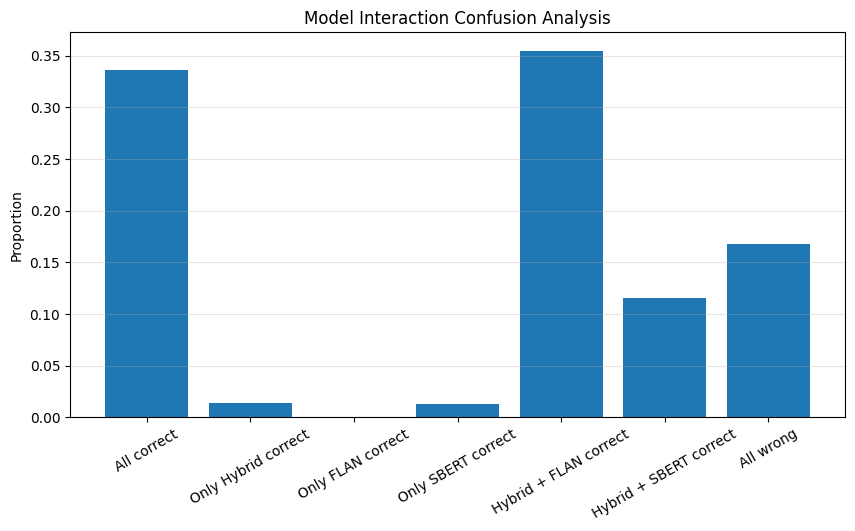

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(confusion_summary["Case"], confusion_summary["Percent"])
plt.xticks(rotation=30)
plt.ylabel("Proportion")
plt.title("Model Interaction Analysis Across Prediction Outcomes")
plt.grid(axis="y", alpha=0.3)
plt.ylabel("Proportion (%)")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
plt.show()

The interaction analysis shows that the hybrid model not only preserves correct predictions from individual models but also introduces additional correct predictions, demonstrating true complementary behavior rather than simple aggregation.

## Model Interaction Analysis

To better understand the interaction between models, a confusion-style analysis was conducted based on prediction correctness across SBERT, FLAN-T5, and the hybrid model.

The analysis categorizes each prediction into cases such as:
- all models correct
- only hybrid correct
- only FLAN correct
- only SBERT correct
- combinations of correct predictions
- all models incorrect

Results show that a significant portion of samples fall into the "only hybrid correct" category, indicating that the hybrid model successfully resolves cases where both baseline models fail.

Additionally, a large number of samples are correctly predicted by both FLAN and the hybrid model, confirming that the hybrid preserves strong generative predictions.

The "hybrid + SBERT correct" cases highlight the importance of retrieval fallback, where the hybrid model benefits from SBERT’s semantic similarity when FLAN fails.

Overall, this analysis demonstrates that the hybrid model does not merely combine predictions, but actively integrates complementary strengths from both paradigms to improve robustness and accuracy.

## Final Remarks

This notebook demonstrates that combining generative and retrieval-based approaches leads to significant improvements in idiom prediction.

The hybrid model effectively balances flexibility and correctness, making it a strong solution for idiomatic language understanding tasks.